In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

In [2]:
df_merged = pd.read_csv("final dataset.csv")

In [3]:
# Drop rows with missing values
df = df_merged.dropna().copy()

In [4]:
le = LabelEncoder()
df["NewsSenti"] = le.fit_transform(df["NewsSenti"].astype(str))
df["sentiment"] = le.fit_transform(df["sentiment"].astype(str))

In [5]:
df.columns = df.columns.str.strip()

# Independent variables (X)
X = df[
    [
        "indexes",
        "NewsSCORE",
        "sentiment_score",
        "NewsSenti",
        "sentiment"	
    ]
]

# Dependent variable (y)
y = df["volatility"]

In [6]:
# Initialize model
lr = LinearRegression()

# Fit model
lr.fit(X, y)

# Predictions
y_pred = lr.predict(X)

# Residuals
df["residuals"] = y - y_pred

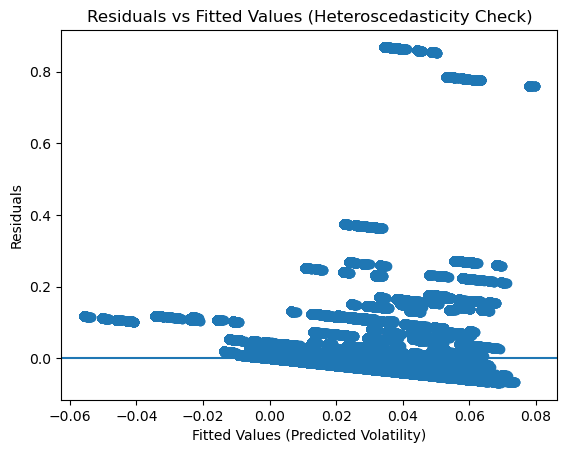

In [7]:
plt.figure()
plt.scatter(y_pred, df["residuals"])
plt.axhline(0)
plt.xlabel("Fitted Values (Predicted Volatility)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Heteroscedasticity Check)")
plt.show()

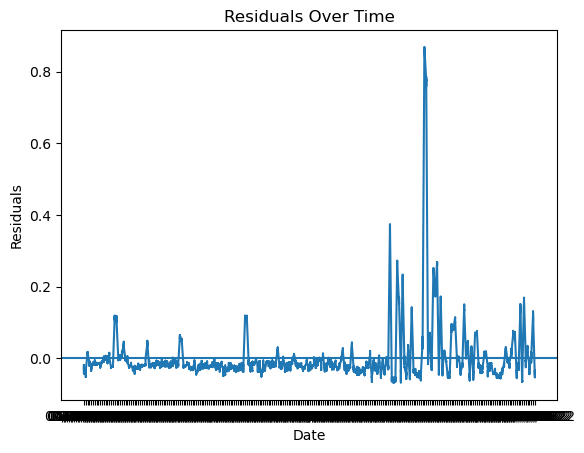

In [8]:
plt.figure()
plt.plot(df["Date Main"], df["residuals"])
plt.axhline(0)
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.title("Residuals Over Time")
plt.show()

In [9]:
# Add constant for statsmodels
X_sm = sm.add_constant(X)

# Fit OLS model
ols_model = sm.OLS(y, X_sm).fit()

# Breusch-Pagan test
bp_test = het_breuschpagan(ols_model.resid, X_sm)

bp_results = {
    "LM Statistic": bp_test[0],
    "LM p-value": bp_test[1],
    "F Statistic": bp_test[2],
    "F p-value": bp_test[3]
}

print(bp_results)


{'LM Statistic': 6667.293952189429, 'LM p-value': 0.0, 'F Statistic': 1350.5460700536842, 'F p-value': 0.0}
